# EDA
For the tables flights, hotels, session and users

# Flights EDA

In [3]:
import pandas as pd

In [4]:
flights = pd.read_csv('data/flights.csv')

In [7]:
flights

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87
1,549482-f5e7931dd7b6460b90b89ea0aaabfc78,YVR,san diego,SAN,1,True,2023-07-25 11:00:00.000000,2023-07-31 11:00:00.000000,1,American Airlines,32.699,-117.215,369.26
2,585745-7f13ca3cb64441e08ba34a3020e7ff7b,LBB,new york,JFK,1,True,2023-07-24 07:00:00.000000,2023-07-29 07:00:00.000000,0,Allegiant Air,40.640,-73.779,407.51
3,596153-eb736cf7fe6f4aaf8c1638e399111ced,YKZ,calgary,YYC,1,True,2023-07-25 15:00:00.000000,2023-07-27 15:00:00.000000,1,WestJet,51.114,-114.020,449.58
4,636526-80cabddfe58c406d9ba90c77f85c66ff,LGA,los angeles,LAX,1,True,2023-07-23 13:00:00.000000,2023-07-26 13:00:00.000000,1,Air New Zealand,33.942,-118.408,691.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13188,544449-e96a99d225be4ca2862bfa16d02f94d9,LGA,chicago,MDW,2,True,2023-03-30 08:00:00.000000,2023-04-01 08:00:00.000000,0,AirTran Airways,41.786,-87.752,389.69
13189,566735-978b549aa0804742883e1a10e57d6790,BOS,indianapolis,IND,1,True,2023-04-02 09:00:00.000000,2023-04-06 09:00:00.000000,1,Allegiant Air,39.717,-86.294,175.15
13190,580611-b8fc699133a8430a935067cd85f68549,JFK,montreal,YUL,1,True,2023-03-31 11:00:00.000000,2023-04-05 11:00:00.000000,0,Royal Jordanian,45.517,-73.417,97.40
13191,588386-233db0f627cf4aaaaeaa9a632daa5ec4,CLE,philadelphia,PHL,1,True,2023-04-04 08:00:00.000000,2023-04-06 08:00:00.000000,2,American Airlines,39.872,-75.241,106.00


In [6]:
flights['destination'].value_counts()

destination
new york        1868
los angeles      983
toronto          707
chicago          677
houston          545
                ... 
buenos aires       1
jaipur             1
hanoi              1
atlanta            1
nice               1
Name: count, Length: 124, dtype: int64

Each row is either one or two way.  Most flights go to new york los angeles and toronto.

In [8]:
# Missing values
flights.isna().sum()

trip_id                      0
origin_airport               0
destination                  0
destination_airport          0
seats                        0
return_flight_booked         0
departure_time               0
return_time                573
checked_bags                 0
trip_airline                 0
destination_airport_lat      0
destination_airport_lon      0
base_fare_usd                0
dtype: int64

In [15]:
flights[flights['return_time'].isna()]['return_flight_booked'].sum()

np.int64(0)

No nan values (only for one way ticket, which is not a mistake)

In [10]:
573/13193

0.04343212309558099

In [9]:
flights.shape

(13193, 13)

In [16]:
flights[flights['return_time'].isna()]

,trip_id,origin_airport,destination,destination_airport,seats,return_flight_booked,departure_time,return_time,checked_bags,trip_airline,destination_airport_lat,destination_airport_lon,base_fare_usd
0,363535-ae2567b185da4e3994607ce71f98a96b,CLT,phoenix,PHX,1,False,2023-01-13 15:00:00.000000,NaN,0,Alaska Airlines,33.535,-112.383,251.87
44,527987-de7cd9869f08412f91a438a47861de35,YHM,dallas,DAL,1,False,2023-01-21 07:00:00.000000,NaN,0,KLM Royal Dutch Airlines,32.847,-96.852,165.01
70,541972-9a2d5e306a1b49b494c81605ec31da02,ORD,portland,PDX,1,False,2023-01-27 16:00:00.000000,NaN,0,Alaska Airlines,45.589,-122.597,251.31
99,559266-dbdd4981e7c541a298d9fd79e38aa9a4,JFK,charlotte,CLT,1,False,2023-02-04 12:00:00.000000,NaN,0,American Airlines,35.214,-80.943,78.18
172,546050-e833643e465d483d95bb0b59a9f2e3f5,YND,calgary,YYC,2,False,2023-02-12 07:00:00.000000,NaN,0,WestJet,51.114,-114.020,558.37
...,...,...,...,...,...,...,...,...,...,...,...,...,...
13037,594985-ea311e37a3704e0aa8f2919686c494c4,YKZ,edmonton,YEG,1,False,2023-07-22 07:00:00.000000,NaN,0,WestJet,53.667,-113.467,233.22
13089,533742-850259863bf24ccea6cc29ce92bef5f2,BIF,san antonio,SKF,1,False,2023-07-13 16:00:00.000000,NaN,1,American Airlines,29.529,-98.279,72.55
13091,471687-fd74894f2a77484eab4d669fd89c82bc,LAX,phoenix,PHX,1,False,2023-07-16 11:00:00.000000,NaN,0,Allegiant Air,33.535,-112.383,48.32
13100,406210-6c29806425804fe2b4da095371e25cfb,ANC,osaka,ITM,1,False,2024-05-23 18:00:00.000000,NaN,0,All Nippon Airways,34.785,135.438,536.61


is each trip id unique?

In [17]:
flights['trip_id'].nunique()

13193

In [18]:
flights.shape

(13193, 13)

 Amount of luggage

In [23]:
import matplotlib.pyplot as plt

In [25]:
flights['checked_bags'].value_counts()

checked_bags
0    6395
1    6084
2     585
3      84
4      26
5      15
6       3
8       1
Name: count, dtype: int64

<Axes: xlabel='checked_bags'>

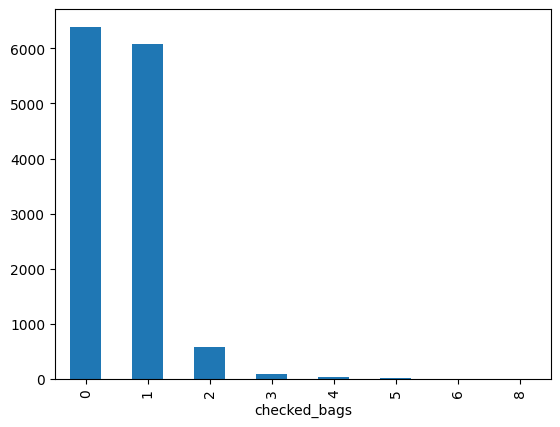

In [24]:
flights['checked_bags'].value_counts().plot(kind='bar')

Amount of seats

In [26]:
flights['seats'].value_counts()

seats
1    11255
2     1426
3      367
4      116
5       16
6       11
7        1
8        1
Name: count, dtype: int64

In [27]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 13193 entries, 0 to 13192
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   trip_id                  13193 non-null  str    
 1   origin_airport           13193 non-null  str    
 2   destination              13193 non-null  str    
 3   destination_airport      13193 non-null  str    
 4   seats                    13193 non-null  int64  
 5   return_flight_booked     13193 non-null  bool   
 6   departure_time           13193 non-null  str    
 7   return_time              12620 non-null  str    
 8   checked_bags             13193 non-null  int64  
 9   trip_airline             13193 non-null  str    
 10  destination_airport_lat  13193 non-null  float64
 11  destination_airport_lon  13193 non-null  float64
 12  base_fare_usd            13193 non-null  float64
dtypes: bool(1), float64(3), int64(2), str(7)
memory usage: 1.2 MB


In [29]:
flights.describe()

,seats,checked_bags,destination_airport_lat,destination_airport_lon,base_fare_usd
count,13193.000000,13193.000000,13193.000000,13193.000000,13193.000000
mean,1.200106,0.584477,38.708329,-90.471100,489.114071
std,0.552416,0.653633,6.642478,29.068945,675.795966
min,1.000000,0.000000,-37.008000,-157.927000,2.410000
25%,1.000000,0.000000,33.942000,-112.383000,198.600000
50%,1.000000,1.000000,39.872000,-87.752000,377.820000
75%,1.000000,1.000000,42.409000,-75.669000,590.590000
max,8.000000,8.000000,55.972000,174.792000,14466.330000


# Hotels EDA

In [54]:
hotels = pd.read_csv('data/hotels.csv')

In [55]:
hotels

,trip_id,hotel_name,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd
0,537922-5e6f8b155a864872aef93d77c7edba79,Rosewood - calgary,10,1,2023-03-04 11:00:00.000000,2023-03-14 11:00:00.000000,139
1,409073-76c1ba377e6242d1b34c8f706b7ae158,Starwood - new york,1,1,2023-03-03 14:02:27.105000,2023-03-05 11:00:00.000000,241
2,515739-5059469839f346c6b9af700d5391dc2f,InterContinental - vancouver,3,1,2023-03-06 18:53:40.515000,2023-03-10 11:00:00.000000,111
3,519912-cfbb8d0f37004bbc9ad43354005d1383,Marriott - san diego,0,1,2023-03-07 12:39:12.690000,2023-03-08 11:00:00.000000,161
4,204943-07ddf3a4d2a34e03befdbd07c78d9aab,Aman Resorts - new york,2,3,2023-03-06 09:40:43.050000,2023-03-08 11:00:00.000000,230
...,...,...,...,...,...,...,...
13767,535341-80ded0bbc8a9411ab73865516ad41ce7,Aman Resorts - chicago,4,3,2023-02-23 13:10:19.020000,2023-02-28 11:00:00.000000,98
13768,512976-4e3c728e61b840b19338946552c2ce02,Starwood - san antonio,4,2,2023-06-23 11:27:09.855000,2023-06-27 11:00:00.000000,281
13769,542254-1ac405fa98c14d4cb882bad182471d12,Rosewood - vancouver,0,1,2023-06-24 20:27:40.590000,2023-06-25 11:00:00.000000,355
13770,549154-100246321b924deea20e1d4b3acbb254,InterContinental - houston,9,1,2023-06-24 11:00:00.000000,2023-07-03 11:00:00.000000,130


Popular hotels

In [56]:
hotels["hotel_name"].value_counts()

hotel_name
Best Western - new york      115
Conrad  - new york           115
Accor - new york             111
Aman Resorts - new york      108
Hilton - new york            107
                            ... 
Crowne Plaza - agra            1
Rosewood - madrid              1
Marriott  - istanbul           1
Starwood  - atlanta            1
InterContinental  - osaka      1
Name: count, Length: 954, dtype: int64

In [57]:
hotel_city_name = hotels['hotel_name'].str.split(' - ', expand=True)

In [58]:
hotel_city_name.columns = ['name', 'city']

In [59]:
hotels_grouped_city = hotel_city_name.groupby('name')['city'].value_counts()

In [60]:
cities_per_hotels = hotel_city_name.groupby('name')['city'].nunique()

In [62]:
hotels_with_name = pd.concat([hotels, hotel_city_name], axis=1).drop(columns=['hotel_name'])

In [63]:
hotels_with_name.describe()

,nights,rooms,hotel_per_room_usd
count,13772.000000,13772.000000,13772.000000
mean,3.616250,1.195396,178.147401
std,3.758377,0.499596,119.019998
min,-2.000000,1.000000,17.000000
25%,1.000000,1.000000,99.000000
50%,2.000000,1.000000,148.000000
75%,5.000000,1.000000,223.000000
max,43.000000,4.000000,1376.000000


In [67]:
hotels_with_name[hotels_with_name['nights']<-1]

,trip_id,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,name,city
6625,540819-34df787c1f3c4138ae4215c54a2d6b23,-2,1,2023-04-16 20:06:42.075000,2023-04-15 11:00:00.000000,103,Best Western,san francisco


In [68]:
hotels_with_name['check_out_time'] = pd.to_datetime(hotels_with_name['check_out_time'])

In [72]:
hotels_with_name['check_out_time'].dt.hour.value_counts()

check_out_time
11    13772
Name: count, dtype: int64

In [73]:
hotels_with_name

,trip_id,nights,rooms,check_in_time,check_out_time,hotel_per_room_usd,name,city
0,537922-5e6f8b155a864872aef93d77c7edba79,10,1,2023-03-04 11:00:00.000000,2023-03-14 11:00:00,139,Rosewood,calgary
1,409073-76c1ba377e6242d1b34c8f706b7ae158,1,1,2023-03-03 14:02:27.105000,2023-03-05 11:00:00,241,Starwood,new york
2,515739-5059469839f346c6b9af700d5391dc2f,3,1,2023-03-06 18:53:40.515000,2023-03-10 11:00:00,111,InterContinental,vancouver
3,519912-cfbb8d0f37004bbc9ad43354005d1383,0,1,2023-03-07 12:39:12.690000,2023-03-08 11:00:00,161,Marriott,san diego
4,204943-07ddf3a4d2a34e03befdbd07c78d9aab,2,3,2023-03-06 09:40:43.050000,2023-03-08 11:00:00,230,Aman Resorts,new york
...,...,...,...,...,...,...,...,...
13767,535341-80ded0bbc8a9411ab73865516ad41ce7,4,3,2023-02-23 13:10:19.020000,2023-02-28 11:00:00,98,Aman Resorts,chicago
13768,512976-4e3c728e61b840b19338946552c2ce02,4,2,2023-06-23 11:27:09.855000,2023-06-27 11:00:00,281,Starwood,san antonio
13769,542254-1ac405fa98c14d4cb882bad182471d12,0,1,2023-06-24 20:27:40.590000,2023-06-25 11:00:00,355,Rosewood,vancouver
13770,549154-100246321b924deea20e1d4b3acbb254,9,1,2023-06-24 11:00:00.000000,2023-07-03 11:00:00,130,InterContinental,houston
